In [1]:
%config InteractiveShell.ast_node_interactivity='last_expr_or_assign'  # always print last expr.
%config InlineBackend.figure_format = 'svg'
%load_ext autoreload
%autoreload 2
%matplotlib inline

import logging
logging.basicConfig(level=logging.INFO)

In [2]:
import pandas
import numpy as np
from tsdm.datasets import Electricity

INFO:numexpr.utils:Note: NumExpr detected 24 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.
INFO:tsdm.config._config:Available Models: {'Latent-ODE', 'M-RNN', 'BRITS', 'SET-TS', 'mTAN', 'NODE', 'TPA', 'N-BEATS', 'TFT', 'ODE-RNN', 'NCDE', 'Informer', 'GRU-ODE-Bayes', 'IP-Net'}
INFO:tsdm.config._config:Available Datasets: {'Physionet 2019', 'MuJoCo', 'Household Consumption', 'tourism1', 'M4', 'Character Trajectories', 'Traffic', 'Human Activity', 'Air Quality', 'tourism2', 'Electricity', 'Air Quality Multi-Site', 'UWAVE', 'Physionet 2012', 'USHCN', 'M3', 'M5'}
INFO:tsdm.config._config:Initializing folder structure
INFO:tsdm.config._config:creating folder /home/rscholz/.tsdm/datasets
INFO:tsdm.config._config:creating folder /home/rscholz/.tsdm/models
INFO:tsdm.config._config:creating folder /home/rscholz/.tsdm/logs
INFO:tsdm.config._config:creating folder /home/rscholz/.tsdm/rawdata
INFO:tsdm.config._config:Create

In [3]:
x = Electricity()

INFO:tsdm.datasets.base._base:Electricity: START loading dataset!
INFO:tsdm.datasets.base._base:Electricity: Rawdata files already exist!
INFO:tsdm.datasets.base._base:Electricity: Dataset files already exist!
INFO:tsdm.datasets.base._base:Electricity: DONE loading dataset!
INFO:tsdm.datasets.base._base:Electricity: START loading dataset!
INFO:tsdm.datasets.base._base:Electricity: Rawdata files already exist!
INFO:tsdm.datasets.base._base:Electricity: Dataset files already exist!
INFO:tsdm.datasets.base._base:Electricity: DONE loading dataset!


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
time,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 00:30:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 00:45:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 01:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 01:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 23:00:00,2.538071,22.048364,1.737619,150.406504,85.365854,303.571429,11.305822,282.828283,68.181818,72.043011,...,276.945039,28200.0,1616.033755,1363.636364,29.986962,5.851375,697.102722,176.961603,651.026393,7621.621622
2014-12-31 23:15:00,2.538071,21.337127,1.737619,166.666667,81.707317,324.404762,11.305822,252.525253,64.685315,72.043011,...,279.800143,28300.0,1569.620253,1340.909091,29.986962,9.947338,671.641791,168.614357,669.354839,6702.702703
2014-12-31 23:30:00,2.538071,20.625889,1.737619,162.601626,82.926829,318.452381,10.175240,242.424242,61.188811,74.193548,...,284.796574,27800.0,1556.962025,1318.181818,27.379400,9.362200,670.763828,153.589316,670.087977,6864.864865


In [4]:
pandas.date_range("2011", "2015", freq="1Y")

DatetimeIndex(['2011-12-31', '2012-12-31', '2013-12-31', '2014-12-31'], dtype='datetime64[ns]', freq='A-DEC')

In [5]:
ds = Electricity().dataset
x = ds.copy()
x = x.resample("1h").sum()
mask = x == 0.0
x[mask] = float('nan')

ymin = x.min().min()
ymax = x.max().max()
xmin = np.datetime64("2010-10")
xmax = np.datetime64("2015-04")

INFO:tsdm.datasets.base._base:Electricity: START loading dataset!
INFO:tsdm.datasets.base._base:Electricity: Rawdata files already exist!
INFO:tsdm.datasets.base._base:Electricity: Dataset files already exist!
INFO:tsdm.datasets.base._base:Electricity: DONE loading dataset!
INFO:tsdm.datasets.base._base:Electricity: START loading dataset!
INFO:tsdm.datasets.base._base:Electricity: Rawdata files already exist!
INFO:tsdm.datasets.base._base:Electricity: Dataset files already exist!
INFO:tsdm.datasets.base._base:Electricity: DONE loading dataset!


numpy.datetime64('2015-04')

In [6]:
xlabels = dates = [str(i) for i in range(2011, 2016)]
xticks = np.array(dates).astype(np.datetime64)
yticks = [1, 1000, 1000000]

[1, 1000, 1000000]

Every year in March time change day (which has only 23 hours) the values between 1:00 am and 2:00 am are zero for all points. Every year in October time change day (which has 25 hours) the values between 1:00 am and 2:00 am aggregate the consumption of two hours. 

In [7]:
import matplotlib.pyplot as plt

In [8]:
plt.style.use("bmh")
def make_figure(cols):
    fig, axes = plt.subplots(ncols=3, nrows=8, figsize=(8.27, 11.69), constrained_layout=True, sharex=True, sharey=True)
    for col, ax in zip(cols, axes.flatten()):
        data = x[col].rolling(4).sum()  # kWH aggregation
        data = data.rolling(24*7).mean() # weekly aggregation
        ax.semilogy(data.index, data.values, lw=1)
        ax.set_ylim(0.1, 1_000_000)
        ax.set_xlim(xmin, xmax)
        ax.set_title(col)
        ax.set_yticks(yticks)
        ax.set_xticks(xticks, labels=xlabels)
    return fig, axes

fig, _ = make_figure(ds.columns)
fig.savefig("Electricity.pdf", orientation = 'portrait')

In [9]:
%matplotlib agg
from matplotlib.backends.backend_pdf import PdfPages
from tqdm.auto import tqdm, trange
plt.style.use("bmh")

L = len(ds.columns)
B = 24

with PdfPages("electricity-booklet.pdf") as pdf:
    for idx in trange(0, L, B):
        cols = ds.columns[idx:idx+B]
        fig, _ = make_figure(cols)
        pdf.savefig(fig)
        plt.close(fig)

  0%|          | 0/16 [00:00<?, ?it/s]

### 2.1 Triplet Format

The data is represented as a set of triplets (time, variable, value). All NaNs are dropped.

In [10]:
from tsdm.encoders.functional import make_dense_triplets, make_sparse_triplets,make_masked_format

In [11]:
dense_x = make_dense_triplets(x)
dense_x

,variable,value
time,,
2011-01-01,MT_124,205.741627
2011-01-01,MT_131,791.666667
2011-01-01,MT_132,130.633573
2011-01-01,MT_156,204.610106
2011-01-01,MT_158,116.363636
...,...,...
2015-01-01,MT_366,4.095963
2015-01-01,MT_367,628.621598
2015-01-01,MT_368,131.886477


### 2.2 Sparse Triplet format

The same as before, but the variable tensor is encoded in a one-hot fashion, and the tensor is stored as a sparse tensor

In [12]:
sparse_x = make_sparse_triplets(x)
sparse_x

,value,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
time,,,,,,,,,,,,,,,,,,,,,
2011-01-01,205.741627,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01,791.666667,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01,130.633573,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01,204.610106,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01,116.363636,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-01-01,4.095963,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2015-01-01,628.621598,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2015-01-01,131.886477,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


### 2.3 Masked Format

Here we get 3 tensors:

- x: the original data
- m: a boolean mask, 1: value observed, 0: value not observed (NaN)
- d: time since the channel was last observed

In [13]:
x, m, d = make_masked_format(x)
display(x, m, d)

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
time,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 20:00:00,8.883249,100.995733,6.950478,745.934959,368.292683,1363.095238,45.223290,1262.626263,367.132867,325.806452,...,1334.047109,158800.0,6810.126582,8954.545455,299.869622,17.554125,1503.072871,435.726210,2753.665689,33621.621622
2014-12-31 21:00:00,10.152284,91.038407,6.950478,648.373984,345.121951,1279.761905,46.353872,1077.441077,305.944056,280.645161,...,1309.064954,154300.0,6599.156118,5909.090909,299.869622,15.798713,1862.159789,619.365609,2648.093842,33135.135135
2014-12-31 22:00:00,7.614213,88.193457,6.950478,644.308943,347.560976,1258.928571,45.223290,1006.734007,286.713287,289.247312,...,1224.839400,141900.0,6544.303797,5500.000000,256.844850,31.012288,2620.719930,781.302170,2717.008798,30378.378378


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
time,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01 01:00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01 02:00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01 03:00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01 04:00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 20:00:00,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2014-12-31 21:00:00,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2014-12-31 22:00:00,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
time,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,...,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00
2011-01-01 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,...,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00
2011-01-01 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,...,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00
2011-01-01 03:00:00,0 days 03:00:00,0 days 03:00:00,0 days 03:00:00,0 days 03:00:00,0 days 03:00:00,0 days 03:00:00,0 days 03:00:00,0 days 03:00:00,0 days 03:00:00,0 days 03:00:00,...,0 days 03:00:00,0 days 03:00:00,0 days 03:00:00,0 days 03:00:00,0 days 03:00:00,0 days 03:00:00,0 days 03:00:00,0 days 03:00:00,0 days 03:00:00,0 days 03:00:00
2011-01-01 04:00:00,0 days 04:00:00,0 days 04:00:00,0 days 04:00:00,0 days 04:00:00,0 days 04:00:00,0 days 04:00:00,0 days 04:00:00,0 days 04:00:00,0 days 04:00:00,0 days 04:00:00,...,0 days 04:00:00,0 days 04:00:00,0 days 04:00:00,0 days 04:00:00,0 days 04:00:00,0 days 04:00:00,0 days 04:00:00,0 days 04:00:00,0 days 04:00:00,0 days 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 20:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,...,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00
2014-12-31 21:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,...,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00
2014-12-31 22:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,...,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00,0 days 01:00:00


## 3. Visualizing the data

In [14]:
df = Electricity().dataset
ΔT = np.diff(df.index)
Δt = ΔT[0].astype("timedelta64[m]")
assert np.all(ΔT == Δt)
N, M = df.shape
# remove first year from the data (useless zeros)
span = np.timedelta64(365, "D") // Δt
df = df.iloc[span:]

INFO:tsdm.datasets.base._base:Electricity: START loading dataset!
INFO:tsdm.datasets.base._base:Electricity: Rawdata files already exist!
INFO:tsdm.datasets.base._base:Electricity: Dataset files already exist!
INFO:tsdm.datasets.base._base:Electricity: DONE loading dataset!
INFO:tsdm.datasets.base._base:Electricity: START loading dataset!
INFO:tsdm.datasets.base._base:Electricity: Rawdata files already exist!
INFO:tsdm.datasets.base._base:Electricity: Dataset files already exist!
INFO:tsdm.datasets.base._base:Electricity: DONE loading dataset!


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
time,,,,,,,,,,,,,,,,,,,,,
2012-01-01 00:15:00,3.807107,22.759602,77.324066,136.178862,70.731707,351.190476,9.609949,279.461279,75.174825,87.096774,...,128.479657,28500.0,1729.957806,1704.545455,15.645372,12.873025,504.828797,63.439065,761.730205,0.000000
2012-01-01 00:30:00,5.076142,22.759602,77.324066,136.178862,73.170732,354.166667,9.044658,279.461279,73.426573,84.946237,...,127.765882,26400.0,1654.008439,1659.090909,15.645372,13.458163,525.021949,60.100167,702.346041,0.000000
2012-01-01 00:45:00,3.807107,22.759602,77.324066,140.243902,69.512195,348.214286,8.479367,279.461279,75.174825,91.397849,...,114.204140,25200.0,1333.333333,1636.363636,15.645372,10.532475,526.777875,56.761269,696.480938,0.000000
2012-01-01 01:00:00,3.807107,22.759602,77.324066,140.243902,75.609756,339.285714,7.348785,279.461279,68.181818,88.172043,...,112.062812,23800.0,1324.894515,1636.363636,15.645372,14.628438,539.947322,63.439065,693.548387,0.000000
2012-01-01 01:15:00,5.076142,22.048364,77.324066,146.341463,73.170732,342.261905,6.783493,265.993266,69.930070,86.021505,...,112.776588,23700.0,1118.143460,1659.090909,15.645372,9.947338,556.628622,68.447412,723.607038,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 23:00:00,2.538071,22.048364,1.737619,150.406504,85.365854,303.571429,11.305822,282.828283,68.181818,72.043011,...,276.945039,28200.0,1616.033755,1363.636364,29.986962,5.851375,697.102722,176.961603,651.026393,7621.621622
2014-12-31 23:15:00,2.538071,21.337127,1.737619,166.666667,81.707317,324.404762,11.305822,252.525253,64.685315,72.043011,...,279.800143,28300.0,1569.620253,1340.909091,29.986962,9.947338,671.641791,168.614357,669.354839,6702.702703
2014-12-31 23:30:00,2.538071,20.625889,1.737619,162.601626,82.926829,318.452381,10.175240,242.424242,61.188811,74.193548,...,284.796574,27800.0,1556.962025,1318.181818,27.379400,9.362200,670.763828,153.589316,670.087977,6864.864865


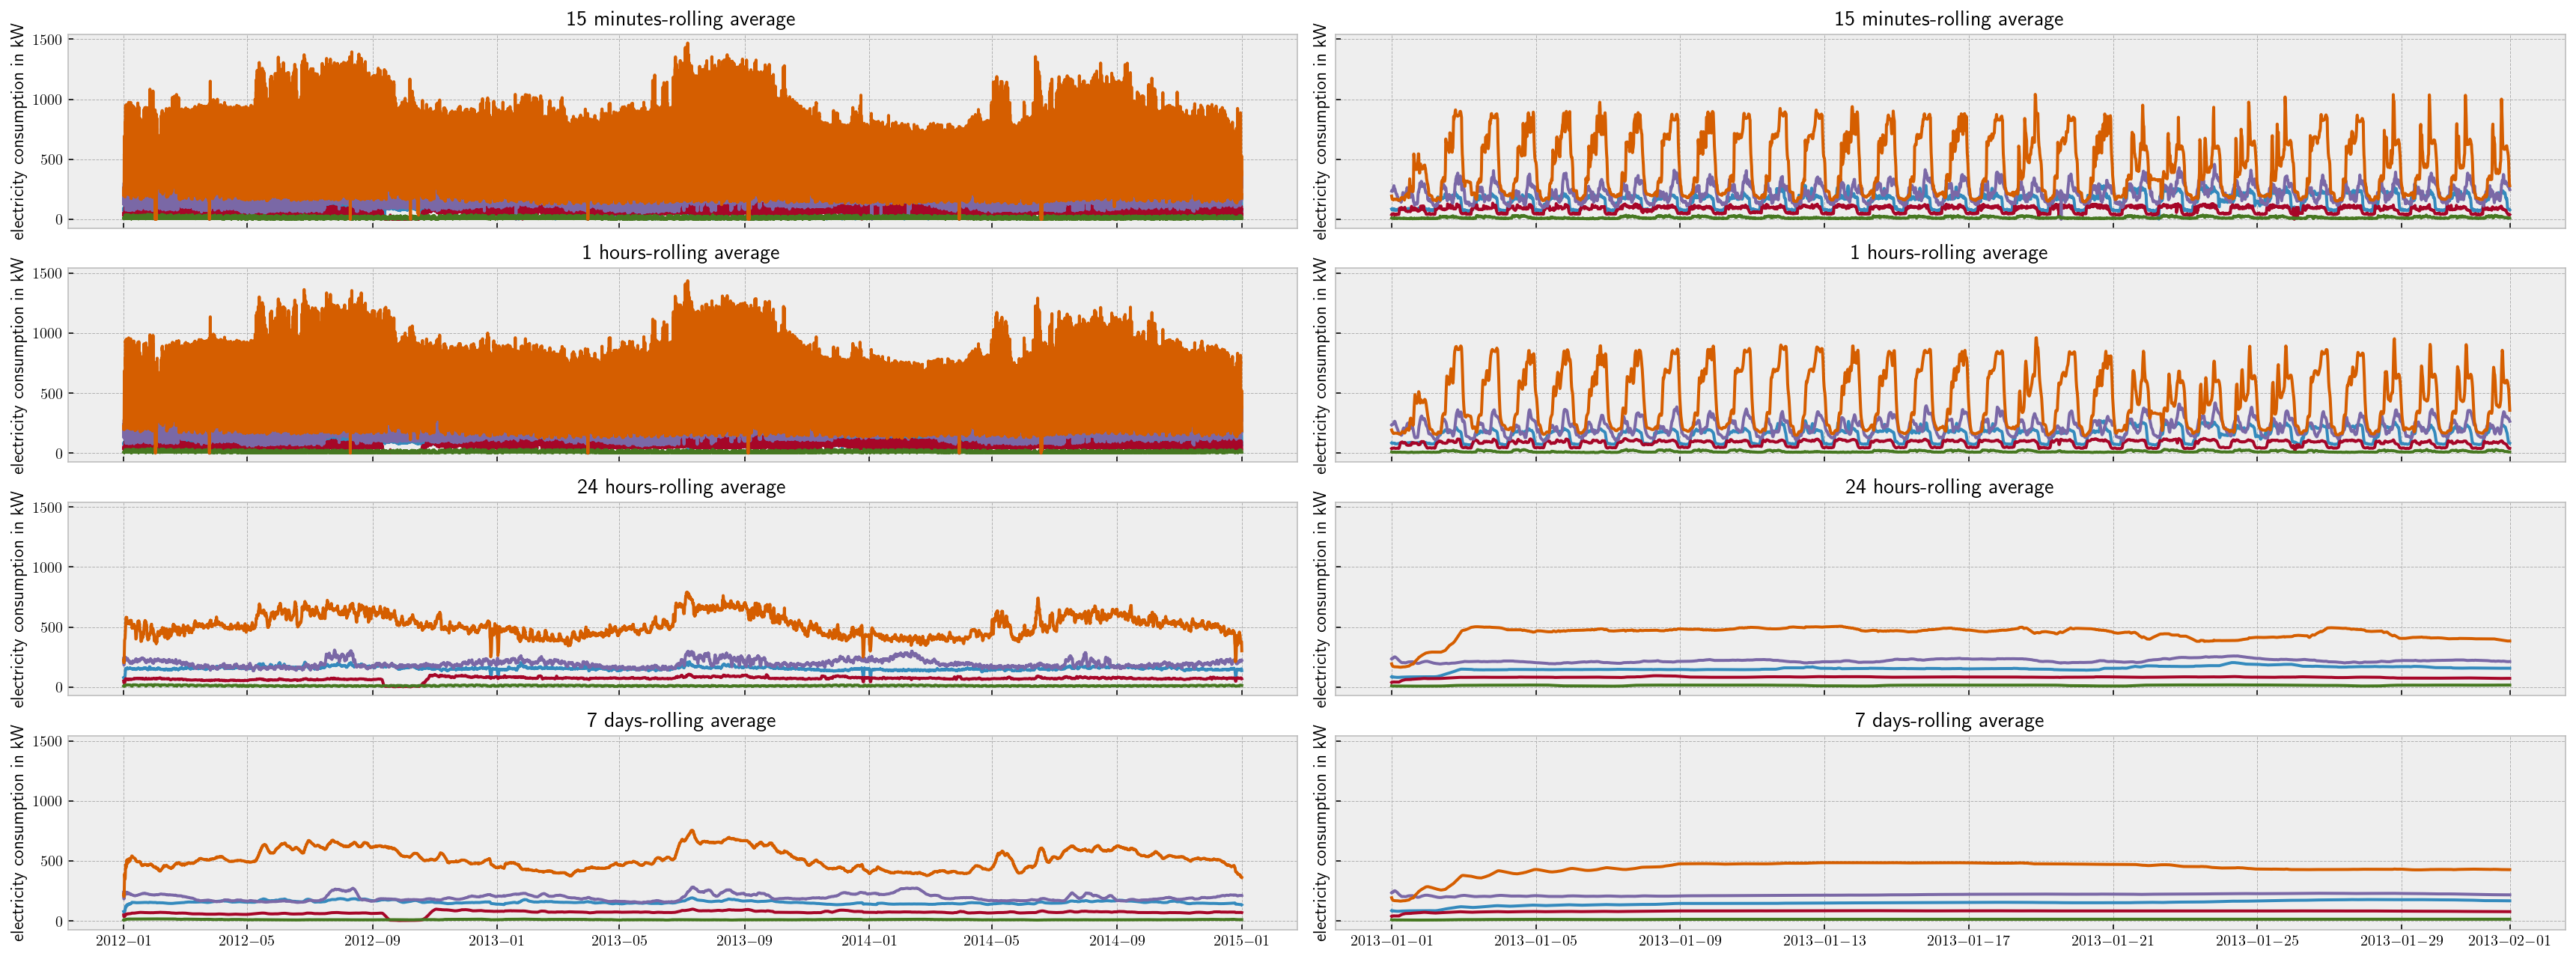

In [15]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
from matplotlib import pyplot as plt

fig, ax = plt.subplots(
    nrows=4, ncols=2, figsize=(24, 9), tight_layout=True, sharex="col", sharey=True
)
ax[1, 0].set_title("1h rolling average")
ax[1, 0].set_title("24h rolling average")
ax[2, 0].set_title("7d rolling average")
selection = np.random.randint(low=0, high=M, size=5)
# selection = [319]

a = np.datetime64("2013-01-01")
b = np.datetime64("2013-02-01")
mask = (df.index >= a) & (df.index <= b)


for k, timedelta in enumerate(
    (Δt, np.timedelta64(1, "h"), np.timedelta64(24, "h"), np.timedelta64(7, "D"))
):
    for l in range(2):
        if l == 0:
            data = df.rolling(window=timedelta // Δt, min_periods=1, axis=0).mean()
        if l == 1:
            a = np.datetime64("2013-01-01")
            b = np.datetime64("2013-02-01")
            mask = (df.index >= a) & (df.index <= b)
            data = (
                df[mask].rolling(window=timedelta // Δt, min_periods=1, axis=0).mean()
            )

        for col in data.iloc[:, selection]:
            ax[k, l].plot(data.index, data[col])
        ax[k, l].set_title(f"{timedelta}-rolling average")
        ax[k, l].set_ylabel("electricity consumption in kW")